## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.



### Ejercicio 1 - Carga, análisis y preparación de datos

#### 1.1 Carga y primer vistazo

In [23]:
df = pd.read_csv('data/titanic.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [25]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Tenemos nulos en age 177, embarked 2 y deck 688, casi el 77%. deck tiene muchos nulos asi que no la tengo en cuenta

Distribución del target (survived):
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


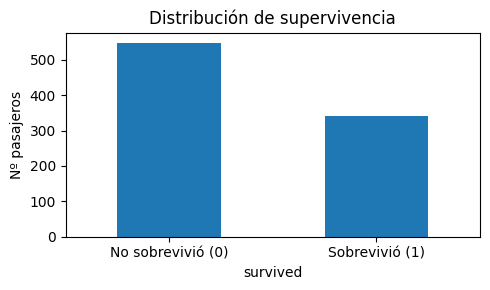

In [26]:
print('Distribución del target (survived):')
print(df['survived'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
df['survived'].value_counts().plot(kind='bar', ax=ax)
ax.set_xticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'], rotation=0)
ax.set_title('Distribución de supervivencia')
ax.set_ylabel('Nº pasajeros')
plt.tight_layout()
plt.show()

El dataset está algo desbalanceado: 62% no sobrevivió vs 38% que sí sobrevivió. Utilizaré accuracy como métrica principal y la completo con precision y recall.

#### 1.2 Preprocesado y Feature Engineering

In [27]:
cols_to_drop = ['class', 'who', 'embark_town', 'alive', 'deck']
df = df.drop(columns=cols_to_drop)

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)
df = pd.get_dummies(df, columns=['embarked'])

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Shape final: {df.shape}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')
df.head()

Shape final: (891, 12)
Nulos restantes: 0


,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,1,0,0,0,1
1,1,1,0,38.0,1,0,71.2833,0,0,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,1,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,0,0,1
4,0,3,1,35.0,0,0,8.0500,1,1,0,0,1


#### 1.3 Train y Test

In [7]:
X = df.drop('survived', axis=1)
y = df['survived']

# Stratify para mantener proporción del target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'\nDistribución target en train:')
print(y_train.value_counts(normalize=True).round(3))

Train: (712, 11)  |  Test: (179, 11)

Distribución target en train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64


#### 1.4 Escalado

Uso StandardScaler ajustado sobre train para evitar data leakage.

In [28]:
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal  = scaler.transform(X_test)

print(f'Media train (post-scaling):  {X_train_scal.mean(axis=0).round(4)}')

Media train (post-scaling):  [-0. -0.  0. -0. -0. -0. -0.  0. -0. -0.  0.]


### Ejercicio 2 - Modelo DL: MLP con GridSearch

Construyo un MLPClassifier.  
Optimizamos hiperparámetros con GridSearchCV.  

Los valores por defecto de cada hiperparámetro son:
- hidden_layer_sizes → (100,) ← default
- activation → 'relu' ← default  
- solver → 'adam' ← default
- alpha → 0.0001 ← default
- learning_rate → 'constant' ← default

In [29]:
param_grid_mlp = {
    'hidden_layer_sizes': [(100,), (100, 50), (100, 50, 25)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

mlp_base = MLPClassifier(max_iter=1000, random_state=42)

grid_mlp = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid_mlp,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print('Iniciando GridSearch MLP...')
grid_mlp.fit(X_train_scal, y_train)

print(f'\nMejor accuracy CV (MLP): {grid_mlp.best_score_:.4f}')
print(f'Mejores hiperparámetros MLP:')
for k, v in grid_mlp.best_params_.items():
    print(f'  {k}: {v}')

Iniciando GridSearch MLP...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Mejor accuracy CV (MLP): 0.8287
Mejores hiperparámetros MLP:
  activation: logistic
  alpha: 0.0001
  hidden_layer_sizes: (100, 50, 25)
  learning_rate: constant
  solver: adam


In [30]:
# conjunto de test
best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_scal)

print(f'Accuracy en test (MLP): {accuracy_score(y_test, y_pred_mlp):.4f}')

Accuracy en test (MLP): 0.7933


### Ejercicio 3 - Modelo Random Forest con GridSearch

In [31]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3]
}

rf_base = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

print('Iniciando GridSearch Random Forest...')
grid_rf.fit(X_train, y_train)

print(f'\nMejor accuracy CV (RF): {grid_rf.best_score_:.4f}')
print(f'Mejores hiperparámetros RF:')
for k, v in grid_rf.best_params_.items():
    print(f'  {k}: {v}')

Iniciando GridSearch Random Forest...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Mejor accuracy CV (RF): 0.8286
Mejores hiperparámetros RF:
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 300


In [32]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f'Accuracy en test (RF): {accuracy_score(y_test, y_pred_rf):.4f}')

Accuracy en test (RF): 0.8156


### Ejercicio 4 - Comparación de modelos

Comparo los dos mejores modelos en tres métricas (accuracy, precision, recall) mediante validación cruzada

In [33]:
def cv_metrics(model, X, y, scoring_list=('accuracy', 'precision', 'recall'), cv=5):
    results = {}
    for metric in scoring_list:
        scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
        results[metric] = scores.mean()
    return results

# Métricas CV del mejor MLP
metrics_mlp = cv_metrics(best_mlp, X_train_scal, y_train)

# Métricas CV del mejor RF (sin escalar)
metrics_rf = cv_metrics(best_rf, X_train, y_train)

print('Métricas CV (media 5 folds):')
print(f"{'Métrica':<12} {'MLP':>10} {'RF':>10}")
print('-' * 34)
for metric in ('accuracy', 'precision', 'recall'):
    print(f"{metric:<12} {metrics_mlp[metric]:>10.4f} {metrics_rf[metric]:>10.4f}")

Métricas CV (media 5 folds):
Métrica             MLP         RF
----------------------------------
accuracy         0.8301     0.8133
precision        0.8608     0.7970
recall           0.6741     0.6890


In [34]:
# Tiempo de entrenamiento
mlp_timer = MLPClassifier(**grid_mlp.best_params_, max_iter=1000, random_state=42)
t0 = time.time()
mlp_timer.fit(X_train_scal, y_train)
t_mlp = time.time() - t0

rf_timer = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
t0 = time.time()
rf_timer.fit(X_train, y_train)
t_rf = time.time() - t0

print(f'Tiempo entrenamiento MLP : {t_mlp:.3f} s')
print(f'Tiempo entrenamiento RF  : {t_rf:.3f} s')

Tiempo entrenamiento MLP : 0.353 s
Tiempo entrenamiento RF  : 0.126 s


In [35]:
resumen = pd.DataFrame({
    'Accuracy CV':  [metrics_mlp['accuracy'],  metrics_rf['accuracy']],
    'Precision CV': [metrics_mlp['precision'], metrics_rf['precision']],
    'Recall CV':    [metrics_mlp['recall'],    metrics_rf['recall']],
    'Tiempo (s)':   [t_mlp, t_rf]
}, index=['MLP (DL)', 'Random Forest'])

resumen.round(4)

,Accuracy CV,Precision CV,Recall CV,Tiempo (s)
MLP (DL),0.8301,0.8608,0.6741,0.3527
Random Forest,0.8133,0.7970,0.6890,0.1263


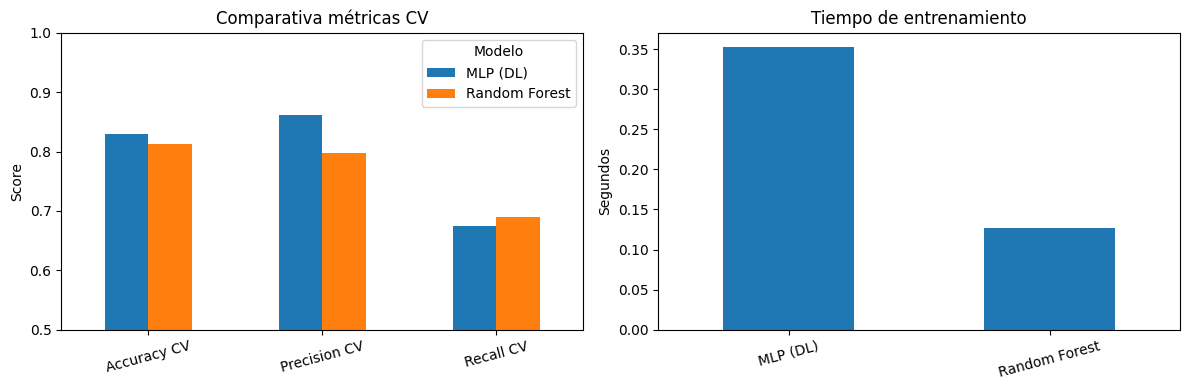

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_df = resumen[['Accuracy CV', 'Precision CV', 'Recall CV']]
metrics_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparativa métricas CV')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(metrics_df.columns, rotation=15)
axes[0].legend(title='Modelo')
axes[0].set_ylabel('Score')

resumen['Tiempo (s)'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Tiempo de entrenamiento')
axes[1].set_xticklabels(resumen.index, rotation=15)
axes[1].set_ylabel('Segundos')

plt.tight_layout()
plt.show()

#### Conclusión

Analizando la tabla y los gráficos:

- **Accuracy y Precision**: ambos modelos obtienen resultados muy similares. Random Forest tiende a ser algo inferior en accuracy en este datasets
- **Recall**: mide cuántos supervivientes reales detectamos. Si hay diferencia, aqui es mejor RandomForest debería ser mínima.
- **Tiempo de entrenamiento**: el MLP es más lento. Random Forest con n_jobs=-1 se ha entrenado en paralelo de manera eficiente.

**Me quedaría con Random Forest** por las siguientes razones:
1. **Rendimiento comparable o superior** con métricas similares, sin necesidad de escalado previo.
2. **Eficiencia**: entrenamientos más rápidos y estables, el MLP creo que necesita más ajuste de max_iter y learning_rate.
3. **Robustez**: el MLP es muy sensible al escalado y al orden de inicialización de pesos; el RF es más robusto.

Creo que también es por el dataset, ya que si fuera mucho mayor, creo que MLP, o Keras/PyTorch sería la elección. Pero esto es intuición en base a los videos

### Ejercicio 4 – Análisis detallado del mejor modelo DL

In [39]:
print('Clasificación – Mejor MLP')
print('=' * 45)
print(classification_report(y_test, y_pred_mlp, target_names=['No sobrevivió', 'Sobrevivió']))

Clasificación – Mejor MLP
               precision    recall  f1-score   support

No sobrevivió       0.78      0.93      0.85       110
   Sobrevivió       0.83      0.58      0.68        69

     accuracy                           0.79       179
    macro avg       0.81      0.75      0.77       179
 weighted avg       0.80      0.79      0.78       179



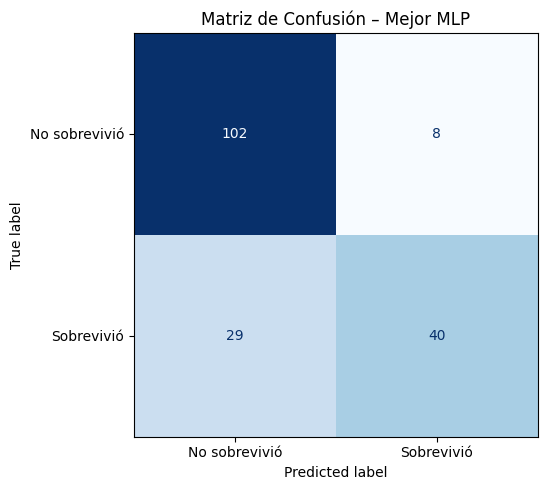

In [18]:
cm = confusion_matrix(y_test, y_pred_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No sobrevivió', 'Sobrevivió'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión – Mejor MLP')
plt.tight_layout()
plt.show()

#### Análisis de la matriz de confusión y la clasificación

matriz de confusión fila a fila:

| | No sobrevivió | Sobrevivió |
|---|---|---|
| **Real: No sobrevivió** | TN (verdaderos negativos) | FP (falsos positivos) |
| **Real: Sobrevivió** | FN (falsos negativos) | TP (verdaderos positivos) |

El modelo muestra un **accuracy global** en torno al 80%.


**Conclusión:** el MLP clasifica bien a la mayoría de los pasajeros. Creo que con más cariño a los datos los resultados mejorarían notablemente, como se ha visto en otras practicas